<a href="https://colab.research.google.com/github/melihdural/Gazi_Bilisim_ML/blob/v3.0/GAZ%C4%B0_ML16_v3_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tabular ML Benchmark: Boosting vs TabNet (Compute-Aware Evaluation)

🎯 Projenin Amacı

Bu proje, tabular veri üzerinde farklı model ailelerinin performansını karşılaştırmak amacıyla geliştirilmiştir.

Özellikle şu soruya cevap aranır:

“Kısıtlı ve gerçekçi compute koşullarında, TabNet gibi derin öğrenme tabanlı modeller gerçekten boosting modellerle rekabet edebilir mi?”

Bu bağlamda iki farklı değerlendirme yaklaşımı uygulanmıştır:
	•	Fair Track → Tüm modellere aynı veri temsili (preprocessing)
	•	Real Track → Her model kendi doğal veri işleme yaklaşımıyla çalışır

⸻

❓ Neden Bu Çalışma Yapıldı?

Tabular veri problemlerinde:
	•	XGBoost, LightGBM, CatBoost gibi boosting modeller uzun süredir dominant
	•	TabNet gibi deep learning modeller ise alternatif olarak öneriliyor

Ancak literatürde ve pratikte şu sorun var:
	•	Karşılaştırmalar çoğu zaman:
	•	ya adil değil (farklı preprocessing)
	•	ya da gerçekçi değil (aşırı tuning / sınırsız compute)

Bu proje:

👉 Adil + gerçekçi + compute-aware bir benchmark kurmayı hedefler

⸻

🧪 Deney Tasarımı

1. Veri Setleri

Benchmark, OpenML üzerinden seçilen farklı tabular veri setleri ile yapılmıştır:

## Model - Dataset Performans Beklentileri

| ID    | Dataset      | Problem Türü / Veri İçeriği | Boyut (Satır x Sütun) | Önerilen Model Tipi | Açıklama |
|------|-------------|-----------------------------|----------------------|---------------------|----------|
| 150  | Covertype   | Coğrafi ve çevresel özelliklerden orman örtüsü tipi sınıflandırma (toprak tipi, yükseklik, eğim, gölge vb.) | ~581K x 54 | XGBoost / LightGBM / CatBoost | Tamamen numeric, yüksek boyutlu ve büyük veri. Sınıflar arası overlap var → kompleks decision boundary gerekir. Boosting modeller üstün. |
| 1590 | Adult       | Bireyin yıllık gelirinin 50K$ üstü/altı tahmini (yaş, eğitim seviyesi, meslek, çalışma saati, medeni durum vb.) | ~48K x 14 | CatBoost | Yoğun kategorik veri (occupation, education, marital-status). Encoding kritik. CatBoost native categorical handling ile avantajlı. |
| 23512| Higgs       | Higgs bozonu tespiti (parçacık çarpışmalarından elde edilen fiziksel ölçümlerle signal/background ayrımı) | ~1M x 28 | XGBoost / LightGBM | Çok büyük ve dense numeric veri. Lineer olmayan kompleks pattern. GPU boosting en iyi performansı verir. |
| 40701| Electricity | Elektrik fiyatının artış/azalış yönü tahmini (zamana bağlı tüketim ve fiyat pattern’leri) | ~45K x 8 | LightGBM / XGBoost | Düşük feature sayısı, zaman bağımlı pattern. Feature interaction önemli. Boosting modeller hızlı ve etkili öğrenir. |
| 40498| Churn       | Müşterinin hizmeti bırakıp bırakmayacağını tahmin (abonelik süresi, kullanım, ödeme davranışı vb.) | ~5K x 20 | Tüm modeller (özellikle boosting) | Küçük veri. Gürültü ve imbalance olabilir. Overfitting riski yüksek → regularization önemli. |
| 40981| Australian  | Kredi başvurusunun onay/red tahmini (finansal durum, kredi geçmişi, demografik özellikler) | 690 x 15 | Tree-based modeller | Küçük ve karışık yapı (numeric + categorical). Veri noisy olabilir. Basit ama stabil modeller avantajlı. |



Bu veri setleri:
	•	farklı boyut
	•	farklı dağılım
	•	farklı feature tipleri

içerecek şekilde seçilmiştir.

⸻

2. Train/Test Ayrımı

Her dataset için:
	•	%80 → train
	•	%20 → test

  ```
    Train → CV
    Test → final evaluation (hiç görülmez)
  ```


⸻

3. Cross Validation

Model değerlendirme:
	•	Stratified K-Fold
	•	Fold sayısı:
	•	dataset büyüklüğüne göre dinamik
	•	Seed:
	•	çoklu seed ile stabilite ölçümü

⸻

⚖️ Track Yapısı

🔹 Fair Track

Amaç:

Modelleri tamamen eşit koşullarda karşılaştırmak

Özellikler:
	•	Ortak preprocessing
	•	OneHotEncoder (feature explosion kontrolü ile)
	•	Aynı input representation

  ```
    Model farkı = sadece algoritma farkı
  ```


⸻

🔹 Real Track

Amaç:

Modelleri gerçek kullanım senaryosuna yakın değerlendirmek

Özellikler:
	•	Model-specific preprocessing
	•	TabNet:
	•	native categorical encoding
	•	embedding kullanımı
	•	Boosting:
	•	klasik preprocessing

  ```
    Model farkı = algoritma + veri işleme farkı
  ```


⸻

⏱️ Compute-Aware Benchmark

Bu benchmark’ın en kritik özelliği:

Sınırsız compute yok.

Her model için:
	•	zaman limiti
	•	fold sayısı
	•	seed sayısı

kontrol edilir.

Model hız sınıfları

```
    MODEL_SPEED_MAP = {
    "LightGBM": "fast",
    "XGBoost": "medium",
    "CatBoost": "medium",
    "TabNet_Fast": "slow",
    "TabNet_Max": "slow",
    }

```


Budget ayarı

```
  BUDGET_CONFIG = {
      "fair": {"folds": 3, "seeds": 1},
      "real": {
          "fast": {"folds": 5, "seeds": 2},
          "medium": {"folds": 3, "seeds": 2},
          "slow": {"folds": 2, "seeds": 1},
      }
  }

```


⸻

🤖 Kullanılan Modeller

Boosting
	•	XGBoost
	•	LightGBM
	•	CatBoost
	•	HistGradientBoosting

Deep Learning
	•	TabNet (Fast)
	•	TabNet (Max)

⸻

⚙️ TabNet Özel Not

TabNet için özel olarak:
	•	categorical embedding kullanımı
	•	internal validation (early stopping)
	•	batch optimizasyonu
	•	compute limit kontrolü

eklenmiştir.

⸻

📈 Değerlendirme Metrikleri

Ana metrik:

```
  Macro F1 Score
```


Ek metrikler:
	•	Accuracy
	•	Balanced Accuracy
	•	AUC
	•	LogLoss

⸻

🧠 XAI (Explainability)

Benchmark sonrası:
	•	En iyi modeller için
	•	SHAP analizi uygulanır

Amaç:
	•	modelin ne öğrendiğini görmek
	•	feature importance analizi

⸻

📊 Çıktılar

Benchmark sonunda:
	•	results_df → tüm ham sonuçlar
	•	summary_df → ortalama + std + CI
	•	best_models_df → dataset bazlı en iyi modeller

CSV olarak export edilir:

```
  Gazi_ML16_Tum_Sonuclar.csv
  Gazi_ML16_En_Iyi_Modeller.csv
  Gazi_ML16_Ham_Sonuclar.csv
```


⸻

🔍 Önemli Tasarım Kararları

1. Fair vs Real ayrımı

→ literatürdeki en büyük hatayı düzeltir

2. Compute limiti

→ gerçek dünya senaryosuna yaklaşır

3. Multi-seed

→ stabil sonuç üretir

4. Dynamic CV

→ küçük datasetleri korur

⸻

⚠️ Kısıtlar
	•	TabNet compute-heavy modeldir
	•	hyperparameter tuning sınırlıdır
	•	tüm datasetler TabNet için uygun değildir

⸻

📌 Sonuçların Doğru Yorumlanması

Bu benchmark şunu ölçer:

“Sınırlı compute altında hangi model daha iyi?”

Şunu ölçmez:

“Sınırsız tuning ile en iyi model hangisi?”

⸻

🚀 Nasıl Çalıştırılır

```
  results_df, trained_models = run_all_tracks()
```


⸻

🧾 Sonuç

Bu proje:
	•	adil
	•	gerçekçi
	•	compute-aware

bir tabular benchmark sunar ve özellikle şu soruya cevap verir:

TabNet, boosting modeller karşısında pratikte ne kadar rekabetçi?

# Bölüm 1 : Kütüphane Kurulumları

In [112]:
# =========================
# PACKAGE INSTALL
# =========================

!pip install -q \
catboost \
lightgbm \
xgboost \
pytorch-tabnet \
scikit-learn \
pandas \
numpy \
matplotlib \
seaborn \
shap

# Bölüm 2 : İçe Aktarmalar ve Sabit Tanımlamaları

In [113]:
# =========================
# IMPORTS
# =========================

import pandas as pd
import numpy as np
import time
import random
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import torch

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, ClassifierMixin, clone

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)

from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    log_loss
)

from sklearn.datasets import fetch_openml

from sklearn.ensemble import HistGradientBoostingClassifier

from pytorch_tabnet.tab_model import TabNetClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from google.colab import sheets
from IPython.display import display

warnings.filterwarnings("default")



# =========================
# TRACK & BUDGET CONFIG
# =========================

TRACK_MODE = "real"  # "fair" veya "real"

MODEL_SPEED_MAP = {
    "XGBoost": "medium",
    "LightGBM": "fast",
    "CatBoost": "medium",
    "TabNet_Fast": "slow",
    "TabNet_Max": "slow",
    "GBT_M": "fast"
}

BUDGET_CONFIG = {
    "fair": {"folds": 3, "seeds": 1},
    "real": {
        "fast": {"folds": 5, "seeds": 2},
        "medium": {"folds": 3, "seeds": 2},
        "slow": {"folds": 2, "seeds": 1},
    }
}

TABNET_DATASET_OVERRIDES = {
    150: {
        "fair": {
            "TabNet_Fast": {"folds": 2, "seeds": 1, "max_epochs": 15},
            "TabNet_Max":  {"skip": True},
        },
        "real": {
            "TabNet_Fast": {"folds": 2, "seeds": 1, "max_epochs": 25},
            "TabNet_Max":  {"folds": 1, "seeds": 1, "max_epochs": 10},
        }
    }
}

MODEL_TIME_LIMIT_SECONDS = {
    "fair": {
        "fast": 300,    # 5 dk
        "medium": 600,  # 10 dk
        "slow": 900,    # 15 dk
    },
    "real": {
        "fast": 900,
        "medium": 1800,
        "slow": 2700,
    }
}


# =========================
# EXPERIMENT SETTINGS
# =========================

SEEDS = [42, 2024, 1337]

OPENML_DATASET_IDS = [150, 1590, 23512, 40701, 40498, 40981]

PRIMARY_METRIC = "Macro_F1"

OUTER_TEST_SIZE = 0.20

TABNET_EPOCHS = 50
BOOSTING_ROUNDS = 300


# =========================
# GLOBAL REPRODUCIBILITY
# =========================

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass


# =========================
# GLOBAL STORAGE
# =========================

results_list = []
trained_models = {}

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Bölüm 3 : Veri Çekme, Bölme ve EDA Fonksiyonları

In [114]:
# =========================
# DATA LOADING & PREP
# =========================

def load_openml_data(dataset_id):
    print(f"--- Veri Seti Yükleniyor: OpenML ID {dataset_id} ---")

    data = fetch_openml(data_id=dataset_id, as_frame=True, parser="auto")
    df = data.frame.copy()

    target_name = data.target.name if hasattr(data.target, "name") else df.columns[-1]

    X = df.drop(columns=[target_name]).copy()
    y = df[target_name].copy()

    metadata = {
        "dataset_id": dataset_id,
        "dataset_name": data.details.get("name", f"DATASET_{dataset_id}").upper(),
    }

    return X, y, metadata


# =========================
# TARGET PREP
# =========================

def prepare_target(y):
    y_processed = y.copy()

    if y_processed.dtype == "object" or str(y_processed.dtype).startswith("category"):
        y_processed = LabelEncoder().fit_transform(y_processed)

    return pd.Series(y_processed).reset_index(drop=True)


# =========================
# SPLIT (SIMPLIFIED)
# =========================

def split_data(X, y, seed):
    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)

    # 🔥 Artık sadece train/test var (academic fix)
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=OUTER_TEST_SIZE,
        random_state=seed,
        stratify=y
    )

    return X_train, X_test, y_train, y_test


# =========================
# EDA (OPTIONAL)
# =========================

def perform_eda(X, y_target, dataset_id, dataset_name):

    # 🔥 compute budget için kapatılabilir
    RUN_EDA = False

    if not RUN_EDA:
        return

    print(f"\n--- OpenML ID {dataset_id} için EDA ---")

    if len(X) > 3000:
        sample_idx = np.random.choice(len(X), 3000, replace=False)
        X = X.iloc[sample_idx]
        y_target = y_target.iloc[sample_idx]

    # sadece numeric kolonlar
    num_cols = X.select_dtypes(include=[np.number]).columns

    if len(num_cols) > 0:
        plt.figure(figsize=(8, 6))
        sns.heatmap(X[num_cols].corr(), cmap="coolwarm")
        plt.title(f"{dataset_name} - Correlation")
        plt.show()


# =========================
# MODEL VISUALIZATION (OPTIONAL)
# =========================

def perform_model_base_plot(*args, **kwargs):
    # 🔥 benchmark sırasında kapalı
    return

# Bölüm 4 : Budget Helper

In [115]:
# =========================
# BUDGET HELPER
# =========================

def get_model_budget(model_name):
    """
    Modele göre kaç fold ve kaç seed kullanılacağını belirler
    """

    if TRACK_MODE == "fair":
        return BUDGET_CONFIG["fair"]["folds"], BUDGET_CONFIG["fair"]["seeds"]

    speed = MODEL_SPEED_MAP.get(model_name, "medium")

    config = BUDGET_CONFIG["real"][speed]

    return config["folds"], config["seeds"]


def get_tabnet_override(dataset_id, track_mode, model_name):
    return (
        TABNET_DATASET_OVERRIDES
        .get(dataset_id, {})
        .get(track_mode, {})
        .get(model_name, None)
    )


def get_model_time_limit(track_mode, model_name):
    speed = MODEL_SPEED_MAP.get(model_name, "medium")
    return MODEL_TIME_LIMIT_SECONDS[track_mode][speed]


# =========================
# OPTIONAL: TIME LIMIT (ileri seviye)
# =========================

GLOBAL_START_TIME = time.time()
MAX_TOTAL_TIME = 3 * 60 * 60  # 3 saat

def is_time_exceeded():
    return (time.time() - GLOBAL_START_TIME) > MAX_TOTAL_TIME

# Bölüm 5 : Ön İşleme

In [116]:
# =========================
# PREPROCESSOR (TRACK AWARE)
# =========================

def build_preprocessor(X, model_name=None):

    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

    # ---------- NUMERIC ----------
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    # ---------- CATEGORICAL ----------
    if TRACK_MODE == "fair":

        # controlled fair
        categorical_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                max_categories=50
            )),
        ])

    else:
        # real track
        if model_name is not None and "TabNet" in model_name:
            categorical_transformer = Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ordinal", OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                ))
            ])
        else:
            categorical_transformer = Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )),
            ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

# Bölüm 6 : Model Tanımlamaları

In [117]:
def get_model_builders(seed, n_classes=2):

    catboost_loss = "Logloss" if n_classes == 2 else "MultiClass"
    xgb_metric = "logloss" if n_classes == 2 else "mlogloss"
    lgbm_objective = "binary" if n_classes == 2 else "multiclass"

    return {

        # -------------------------
        # XGBOOST
        # -------------------------
        "XGBoost": lambda: XGBClassifier(
            random_state=seed,
            eval_metric=xgb_metric,
            n_jobs=-1,
            tree_method="hist",
            device="cuda",
            max_depth=6,
            n_estimators=BOOSTING_ROUNDS,
            learning_rate=0.1,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
        ),

        # -------------------------
        # LIGHTGBM
        # -------------------------
        "LightGBM": lambda: LGBMClassifier(
            random_state=seed,
            device="gpu",
            n_jobs=-1,
            objective=lgbm_objective,
            n_estimators=BOOSTING_ROUNDS,
            learning_rate=0.1,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            verbosity=-1,
            min_child_samples=20,
        ),

        # -------------------------
        # CATBOOST (SAFE GPU/CPU)
        # -------------------------
        "CatBoost": lambda: CatBoostClassifier(
            random_state=seed,
            verbose=0,
            task_type="GPU" if torch.cuda.is_available() else "CPU",
            **({"devices": "0"} if torch.cuda.is_available() else {}),
            iterations=BOOSTING_ROUNDS,
            learning_rate=0.1,
            depth=6,
            loss_function=catboost_loss,
        ),

        # -------------------------
        # TABNET (FAST)
        # -------------------------
        "TabNet_Fast": lambda: TabNetClassifier(
            n_d=16,
            n_a=16,
            n_steps=5,
            gamma=1.3,
            seed=seed,
            verbose=0,
            device_name="cuda",
            optimizer_params=dict(lr=1e-2),
        ),

        # -------------------------
        # TABNET (MAX)
        # -------------------------
        "TabNet_Max": lambda: TabNetClassifier(
            n_d=32,
            n_a=32,
            n_steps=7,
            gamma=1.5,
            seed=seed,
            verbose=0,
            device_name="cuda",
            optimizer_params=dict(lr=5e-3),
        ),

        # -------------------------
        # HIST GBT
        # -------------------------
        "GBT_M": lambda: HistGradientBoostingClassifier(
            max_depth=5,
            max_iter=BOOSTING_ROUNDS,
            learning_rate=0.1,
            random_state=seed,
        ),
    }

# Bölüm 7 : Model Fit

In [118]:
class CatBoostNativePipeline(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        self.feature_names_ = None
        self.numeric_features_ = None
        self.cat_features_ = None
        self.numeric_fill_values_ = None
        self.cat_fill_values_ = None

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("CatBoostNativePipeline expects X as a pandas DataFrame.")

        X_fit = X.copy()

        self.feature_names_ = X_fit.columns.tolist()
        self.numeric_features_ = X_fit.select_dtypes(include=[np.number]).columns.tolist()
        self.cat_features_ = X_fit.select_dtypes(exclude=[np.number]).columns.tolist()

        if self.numeric_features_:
            X_fit[self.numeric_features_] = X_fit[self.numeric_features_].apply(pd.to_numeric, errors="coerce")
            self.numeric_fill_values_ = X_fit[self.numeric_features_].median()
            X_fit[self.numeric_features_] = X_fit[self.numeric_features_].fillna(self.numeric_fill_values_)
        else:
            self.numeric_fill_values_ = pd.Series(dtype=float)

        self.cat_fill_values_ = {}
        for col in self.cat_features_:
            # KRITIK FIX
            series = X_fit[col].astype(object)
            mode = series.mode(dropna=True)
            fill_value = mode.iloc[0] if not mode.empty else "__missing__"
            self.cat_fill_values_[col] = fill_value
            X_fit[col] = series.fillna(fill_value).astype(str)

        self.model.fit(
            X_fit[self.feature_names_],
            y,
            cat_features=self.cat_features_,
            verbose=False
        )
        return self

    def transform_features(self, X):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("CatBoostNativePipeline expects X as a pandas DataFrame.")

        X_t = X.copy()[self.feature_names_]

        if self.numeric_features_:
            X_t[self.numeric_features_] = X_t[self.numeric_features_].apply(pd.to_numeric, errors="coerce")
            X_t[self.numeric_features_] = X_t[self.numeric_features_].fillna(self.numeric_fill_values_)

        for col in self.cat_features_:
            fill_value = self.cat_fill_values_.get(col, "__missing__")
            # KRITIK FIX
            X_t[col] = X_t[col].astype(object).fillna(fill_value).astype(str)

        return X_t

    def predict(self, X):
        return self.model.predict(self.transform_features(X))

    def predict_proba(self, X):
        return self.model.predict_proba(self.transform_features(X))

    def get_feature_names_out(self):
        return np.array(self.feature_names_)

class TabNetPipeline(BaseEstimator, ClassifierMixin):
    def __init__(self, model, max_epochs=TABNET_EPOCHS):
        self.model = model
        self.max_epochs = max_epochs
        self.feature_names_ = None
        self.num_cols_ = None
        self.cat_cols_ = None
        self.num_fill_values_ = None
        self.cat_mapping_ = None
        self.cat_idxs = None
        self.cat_dims = None

    def fit(self, X, y):
        X_df = X.copy()

        self.feature_names_ = X_df.columns.tolist()
        self.num_cols_ = X_df.select_dtypes(include=[np.number]).columns.tolist()
        self.cat_cols_ = X_df.select_dtypes(exclude=[np.number]).columns.tolist()

        if self.num_cols_:
            X_df[self.num_cols_] = X_df[self.num_cols_].apply(pd.to_numeric, errors="coerce")
            self.num_fill_values_ = X_df[self.num_cols_].median()
            X_df[self.num_cols_] = X_df[self.num_cols_].fillna(self.num_fill_values_)
        else:
            self.num_fill_values_ = pd.Series(dtype=float)

        self.cat_mapping_ = {}
        cat_idxs = []
        cat_dims = []

        for i, col in enumerate(self.feature_names_):
            if col in self.cat_cols_:
                series = X_df[col].astype(object).fillna("__missing__").astype(str)

                categories = pd.Index(sorted(series.unique().tolist()))
                mapping = {cat: idx for idx, cat in enumerate(categories)}

                self.cat_mapping_[col] = mapping
                X_df[col] = series.map(mapping).astype(np.int64)

                cat_idxs.append(i)
                cat_dims.append(len(mapping) + 1)

        self.cat_idxs = cat_idxs
        self.cat_dims = cat_dims

        X_np = X_df[self.feature_names_].values.astype(np.float32)
        y_np = np.asarray(y)

        self.model.fit(
            X_np,
            y_np,
            max_epochs=self.max_epochs,
            patience=10,
            batch_size=4096,
            virtual_batch_size=512,
        )
        return self

    def transform(self, X):
        X_df = X.copy()[self.feature_names_]

        if self.num_cols_:
            X_df[self.num_cols_] = X_df[self.num_cols_].apply(pd.to_numeric, errors="coerce")
            X_df[self.num_cols_] = X_df[self.num_cols_].fillna(self.num_fill_values_)

        for col in self.cat_cols_:
            series = X_df[col].astype(object).fillna("__missing__").astype(str)
            mapping = self.cat_mapping_[col]
            unknown_code = len(mapping)
            X_df[col] = series.map(lambda v: mapping.get(v, unknown_code)).astype(np.int64)

        return X_df[self.feature_names_].values.astype(np.float32)

    def predict(self, X):
        return self.model.predict(self.transform(X))

    def predict_proba(self, X):
        return self.model.predict_proba(self.transform(X))


# =========================
# MODEL FIT
# =========================

def fit_model(model_name, model, X_train, y_train, max_epochs=None):

    if model_name == "CatBoost":
        fitted_model = CatBoostNativePipeline(model=clone(model))
        fitted_model.fit(X_train, y_train)
        return fitted_model

    if "TabNet" in model_name:
        # önce geçici pipeline ile cat bilgilerini çıkar
        temp_pipeline = TabNetPipeline(
            model=model,
            max_epochs=max_epochs if max_epochs is not None else TABNET_EPOCHS
        )

        X_df = X_train.copy()
        feature_names = X_df.columns.tolist()
        cat_cols = X_df.select_dtypes(exclude=[np.number]).columns.tolist()

        cat_idxs = []
        cat_dims = []

        for i, col in enumerate(feature_names):
            if col in cat_cols:
                series = X_df[col].astype(object).fillna("__missing__").astype(str)
                cat_idxs.append(i)
                cat_dims.append(series.nunique() + 1)

        # modeli doğru parametrelerle yeniden oluştur
        fitted_model_raw = TabNetClassifier(
            n_d=model.n_d,
            n_a=model.n_a,
            n_steps=model.n_steps,
            gamma=model.gamma,
            seed=model.seed,
            verbose=model.verbose,
            device_name=model.device_name,
            optimizer_params=model.optimizer_params,
            cat_idxs=cat_idxs,
            cat_dims=cat_dims,
        )

        fitted_model = TabNetPipeline(
            model=fitted_model_raw,
            max_epochs=max_epochs if max_epochs is not None else TABNET_EPOCHS
        )
        fitted_model.fit(X_train, y_train)
        return fitted_model

    preprocessor = build_preprocessor(X_train, model_name=model_name)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(model))
    ])

    pipeline.fit(X_train, y_train)
    return pipeline

# Bölüm 8 : Ana Eğitim Döngüsü (Training & Cross-Validation)

In [119]:
def run_benchmark(track_mode):

    global TRACK_MODE
    TRACK_MODE = track_mode

    print(f"\n{'='*60}")
    print(f"RUNNING TRACK: {TRACK_MODE.upper()}")
    print(f"{'='*60}")

    results_list = []
    trained_models = {}

    for dataset_id in OPENML_DATASET_IDS:

        X_raw, y_raw, metadata = load_openml_data(dataset_id)
        dataset_name = f"{metadata['dataset_name']} | Id: {dataset_id}"
        y_processed = prepare_target(y_raw)

        perform_eda(X_raw, y_processed, dataset_id, dataset_name)

        outer_seed = 42
        set_global_seed(outer_seed)

        X_train, X_test, y_train, y_test = train_test_split(
            X_raw,
            y_processed,
            test_size=OUTER_TEST_SIZE,
            random_state=outer_seed,
            stratify=y_processed
        )

        n_classes = len(np.unique(y_train))

        for model_name, model_builder in get_model_builders(outer_seed, n_classes).items():

            folds, seeds_to_use = get_model_budget(model_name)

            tabnet_override = None
            if "TabNet" in model_name:
                tabnet_override = get_tabnet_override(dataset_id, TRACK_MODE, model_name)

            if tabnet_override is not None:
                if tabnet_override.get("skip", False):
                    print(f"Atlandı: {model_name} | Dataset: {dataset_id} | Track: {TRACK_MODE}")
                    continue

                folds = tabnet_override.get("folds", folds)
                seeds_to_use = tabnet_override.get("seeds", seeds_to_use)

            n_samples = len(X_train)

            if n_samples < 5000:
                folds = min(folds, 5)
            elif n_samples < 20000:
                folds = min(folds, 4)
            else:
                folds = min(folds, 3)

            class_counts = np.bincount(np.asarray(y_train))
            min_class_count = np.min(class_counts[class_counts > 0])
            folds = max(2, min(folds, min_class_count))

            for seed in SEEDS[:seeds_to_use]:

                model_time_limit = get_model_time_limit(TRACK_MODE, model_name)
                model_start_time = time.time()

                print(
                    f"Eğitiliyor: {model_name} | Dataset: {dataset_id} | "
                    f"Seed: {seed} | Track: {TRACK_MODE} | Limit: {model_time_limit}s"
                )

                set_global_seed(seed)

                timeout_hit = False
                cv_scores = []

                skf = StratifiedKFold(
                    n_splits=folds,
                    shuffle=True,
                    random_state=seed
                )

                try:
                    # CV
                    for train_idx, val_idx in skf.split(X_train, y_train):
                        if (time.time() - model_start_time) > model_time_limit:
                            timeout_hit = True
                            break

                        X_kf_train = X_train.iloc[train_idx]
                        X_kf_val = X_train.iloc[val_idx]
                        y_kf_train = y_train.iloc[train_idx]
                        y_kf_val = y_train.iloc[val_idx]

                        model = model_builder()

                        fitted_model = fit_model(
                            model_name=model_name,
                            model=model,
                            X_train=X_kf_train,
                            y_train=y_kf_train,
                            max_epochs=tabnet_override.get("max_epochs") if tabnet_override else None
                        )

                        y_val_pred = fitted_model.predict(X_kf_val)
                        macro_f1 = f1_score(y_kf_val, y_val_pred, average="macro")
                        cv_scores.append(macro_f1)

                    if timeout_hit or len(cv_scores) == 0:
                        elapsed_sec = time.time() - model_start_time
                        print(f"⏱ Timeout | {model_name} | Dataset: {dataset_id} | Seed: {seed}")

                        results_list.append({
                            "Dataset": dataset_id,
                            "Dataset_Name": dataset_name,
                            "Seed": seed,
                            "Model": model_name,
                            "Track_Mode": TRACK_MODE,
                            "CV_Macro_F1_Mean": np.nan,
                            "CV_Macro_F1_Std": np.nan,
                            "Test_Macro_F1": np.nan,
                            "Primary_Metric_Value": np.nan,
                            "Elapsed_Seconds": elapsed_sec,
                            "Timed_Out": 1,
                        })
                        continue

                    cv_mean = np.mean(cv_scores)
                    cv_std = np.std(cv_scores, ddof=1) if len(cv_scores) > 1 else 0.0

                    if (time.time() - model_start_time) > model_time_limit:
                        elapsed_sec = time.time() - model_start_time
                        print(f"⏱ Timeout before final fit | {model_name} | Dataset: {dataset_id} | Seed: {seed}")

                        results_list.append({
                            "Dataset": dataset_id,
                            "Dataset_Name": dataset_name,
                            "Seed": seed,
                            "Model": model_name,
                            "Track_Mode": TRACK_MODE,
                            "CV_Macro_F1_Mean": np.nan,
                            "CV_Macro_F1_Std": np.nan,
                            "Test_Macro_F1": np.nan,
                            "Primary_Metric_Value": np.nan,
                            "Elapsed_Seconds": elapsed_sec,
                            "Timed_Out": 1,
                        })
                        continue

                    # Final fit
                    final_model = model_builder()

                    fitted_final_model = fit_model(
                        model_name=model_name,
                        model=final_model,
                        X_train=X_train,
                        y_train=y_train,
                        max_epochs=tabnet_override.get("max_epochs") if tabnet_override else None
                    )

                    y_test_pred = fitted_final_model.predict(X_test)
                    test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")

                    elapsed_sec = time.time() - model_start_time

                    if elapsed_sec > model_time_limit:
                        print(f"⏱ Timeout after final fit | {model_name} | Dataset: {dataset_id} | Seed: {seed}")

                        results_list.append({
                            "Dataset": dataset_id,
                            "Dataset_Name": dataset_name,
                            "Seed": seed,
                            "Model": model_name,
                            "Track_Mode": TRACK_MODE,
                            "CV_Macro_F1_Mean": np.nan,
                            "CV_Macro_F1_Std": np.nan,
                            "Test_Macro_F1": np.nan,
                            "Primary_Metric_Value": np.nan,
                            "Elapsed_Seconds": elapsed_sec,
                            "Timed_Out": 1,
                        })
                        continue

                    results_list.append({
                        "Dataset": dataset_id,
                        "Dataset_Name": dataset_name,
                        "Seed": seed,
                        "Model": model_name,
                        "Track_Mode": TRACK_MODE,
                        "CV_Macro_F1_Mean": cv_mean,
                        "CV_Macro_F1_Std": cv_std,
                        "Test_Macro_F1": test_macro_f1,
                        "Primary_Metric_Value": cv_mean,
                        "Elapsed_Seconds": elapsed_sec,
                        "Timed_Out": 0,
                    })

                    trained_models[(track_mode, dataset_id, seed, model_name)] = {
                        "model": fitted_final_model,
                        "X_test": X_test,
                        "X_train": X_train,
                        "dataset_name": dataset_name,
                        "cv_score": cv_mean,
                        "elapsed_seconds": elapsed_sec,
                    }

                except Exception as e:
                    elapsed_sec = time.time() - model_start_time
                    print(f"HATA | {model_name} | Dataset: {dataset_id} | Seed: {seed} | {e}")

                    results_list.append({
                        "Dataset": dataset_id,
                        "Dataset_Name": dataset_name,
                        "Seed": seed,
                        "Model": model_name,
                        "Track_Mode": TRACK_MODE,
                        "CV_Macro_F1_Mean": np.nan,
                        "CV_Macro_F1_Std": np.nan,
                        "Test_Macro_F1": np.nan,
                        "Primary_Metric_Value": np.nan,
                        "Elapsed_Seconds": elapsed_sec,
                        "Timed_Out": 1,
                    })

    results_df = pd.DataFrame(results_list)
    return results_df, trained_models

# Bölüm 9 : Eğitimleri Başlat

In [120]:
# =========================
# BÖLÜM 9 : RUN BOTH TRACKS (FINAL)
# =========================

def run_all_tracks():

    all_results = []
    all_models = {}

    total_start_time = time.time()  # 🔥 GLOBAL TOTAL TIMER

    for mode in ["fair", "real"]:

        print(f"\n>>> TRACK BAŞLIYOR: {mode.upper()}")

        results_df, trained_models = run_benchmark(mode)

        all_results.append(results_df)

        for k, v in trained_models.items():
            all_models[k] = v

    final_results_df = pd.concat(all_results, ignore_index=True)

    total_minutes = (time.time() - total_start_time) / 60

    print(f"\nTÜM TRACKLER TAMAMLANDI")
    print(f"Toplam süre (tüm benchmark): {total_minutes:.2f} dakika")

    return final_results_df, all_models


# =========================
# EXECUTION
# =========================

results_df, trained_models = run_all_tracks()

print("\nBenchmark tamamlandı.")
print(f"Toplam kayıt sayısı: {len(results_df)}")


>>> TRACK BAŞLIYOR: FAIR

RUNNING TRACK: FAIR
--- Veri Seti Yükleniyor: OpenML ID 150 ---
Eğitiliyor: XGBoost | Dataset: 150 | Seed: 42 | Track: fair | Limit: 600s


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Eğitiliyor: LightGBM | Dataset: 150 | Seed: 42 | Track: fair | Limit: 300s


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature n

Eğitiliyor: CatBoost | Dataset: 150 | Seed: 42 | Track: fair | Limit: 600s


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Eğitiliyor: GBT_M | Dataset: 40981 | Seed: 2024 | Track: real | Limit: 900s


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



TÜM TRACKLER TAMAMLANDI
Toplam süre (tüm benchmark): 85.85 dakika

Benchmark tamamlandı.
Toplam kayıt sayısı: 95


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Bölüm 10: SHAP - XAI

In [121]:
def _extract_shap_payload(model, X):

    # CatBoost native
    if isinstance(model, CatBoostNativePipeline):
        X_t = model.transform_features(X)
        feature_names = model.get_feature_names_out().tolist()
        return model.model, X_t, feature_names

    # TabNet
    if isinstance(model, TabNetPipeline):
        X_t = model.transform(X)
        feature_names = [f"f{i}" for i in range(X_t.shape[1])]
        return model.model, X_t, feature_names

    # sklearn pipeline
    if isinstance(model, Pipeline) and "preprocessor" in model.named_steps:
        X_t = model.named_steps["preprocessor"].transform(X)
        feature_names = model.named_steps["preprocessor"].get_feature_names_out().tolist()
        return model.named_steps["model"], X_t, feature_names

    # fallback
    X_np = np.asarray(X)
    feature_names = list(X.columns) if isinstance(X, pd.DataFrame) else [f"f{i}" for i in range(X_np.shape[1])]
    return model, X_np, feature_names

def perform_posthoc_shap(results_df, trained_models, sample_size=500):

    if results_df.empty:
        print("SHAP atlandı: results_df boş")
        return

    print("\n===== SHAP ANALİZİ (POST-HOC) =====")

    # -------------------------
    # TRACK BAZLI AYIR
    # -------------------------
    for track in results_df["Track_Mode"].unique():

        print(f"\n--- TRACK: {track.upper()} ---")

        track_df = results_df[results_df["Track_Mode"] == track]

        # -------------------------
        # BEST MODEL (CV üzerinden!)
        # -------------------------
        best_models_df = (
            track_df
            .groupby(["Dataset", "Model"], as_index=False)["Primary_Metric_Value"]
            .mean()
        )

        best_models_df = best_models_df.loc[
            best_models_df.groupby("Dataset")["Primary_Metric_Value"].idxmax()
        ]

        # -------------------------
        # SHAP LOOP
        # -------------------------
        for dataset_id in best_models_df["Dataset"].unique():

            row = best_models_df[best_models_df["Dataset"] == dataset_id].iloc[0]
            model_name = row["Model"]

            # 🔥 TÜM ADAY MODELLERİ BUL
            candidate_keys = [
                k for k in trained_models
                if k[0] == track and k[1] == dataset_id and k[3] == model_name
            ]

            if not candidate_keys:
                print(f"SHAP atlandı | Dataset: {dataset_id}")
                continue

            # 🔥 EN İYİ SEED SEÇ (CRITICAL FIX)
            best_key = max(candidate_keys, key=lambda k: trained_models[k]["cv_score"])

            payload = trained_models[best_key]

            model = payload["model"]
            X_test = payload["X_test"]
            dataset_name = payload["dataset_name"]

            try:
                print(f"\nSHAP → {dataset_name} | Model: {model_name} | Track: {track}")

                # sample (compute control)
                if isinstance(X_test, pd.DataFrame) and len(X_test) > sample_size:
                    X_sample = X_test.sample(sample_size, random_state=42)
                else:
                    X_sample = X_test

                shap_model, shap_input, feature_names = _extract_shap_payload(model, X_sample)

                # sadece tree modeller
                if not hasattr(shap_model, "feature_importances_"):
                    print("SHAP atlandı (tree model değil)")
                    continue

                explainer = shap.TreeExplainer(shap_model)
                shap_values = explainer.shap_values(shap_input)

                if isinstance(shap_values, list):
                    shap_values = shap_values[0]

                plt.figure(figsize=(8, 5))
                shap.summary_plot(shap_values, shap_input, plot_type="bar", show=False)
                plt.title(f"{dataset_name} | {model_name} | {track}")
                plt.tight_layout()
                plt.show()

            except Exception as e:
                print(f"SHAP başarısız | Dataset: {dataset_name} | Hata: {e}")

# Bölüm 11 : Sonuç Tablosu ve Modellerin Kıyaslanması


TÜM MODELLERİN METRİK SONUÇLARI

--- DATASET BAZLI EN İYİ MODELLER ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Track_Mode,Dataset,Dataset_Name,Model,CV_Macro_F1_Mean,CV_Macro_F1_Std,CV_Macro_F1_CI95,Test_Macro_F1_Mean,Test_Macro_F1_Std,Test_Macro_F1_CI95,Primary_Metric_Mean,Primary_Metric_Std,Primary_Metric_CI95,Rank
0,fair,150,COVERTYPE | Id: 150,XGBoost,0.8584,NaN,NaN,0.8609,NaN,NaN,0.8584,NaN,NaN,1.0
6,real,150,COVERTYPE | Id: 150,XGBoost,0.8570,0.0019,0.0026,0.8609,0.0,0.0000,0.8570,0.0019,0.0026,1.0
7,real,1590,ADULT | Id: 1590,XGBoost,0.8128,0.0011,0.0015,0.8167,0.0,0.0000,0.8128,0.0011,0.0015,1.0
1,fair,1590,ADULT | Id: 1590,CatBoost,0.8121,NaN,NaN,0.8158,NaN,NaN,0.8121,NaN,NaN,1.0
2,fair,23512,HIGGS | Id: 23512,LightGBM,0.7230,NaN,NaN,0.7246,NaN,NaN,0.7230,NaN,NaN,1.0
8,real,23512,HIGGS | Id: 23512,LightGBM,0.7228,0.0004,0.0005,0.7245,0.0,0.0001,0.7228,0.0004,0.0005,1.0
9,real,40498,WINE-QUALITY-WHITE | Id: 40498,LightGBM,0.3818,0.0102,0.0141,0.4317,0.0,0.0000,0.3818,0.0102,0.0141,1.0
3,fair,40498,WINE-QUALITY-WHITE | Id: 40498,XGBoost,0.3559,NaN,NaN,0.4312,NaN,NaN,0.3559,NaN,NaN,1.0
10,real,40701,CHURN | Id: 40701,CatBoost,0.9027,0.0030,0.0041,0.9097,0.0,0.0000,0.9027,0.0030,0.0041,1.0
4,fair,40701,CHURN | Id: 40701,CatBoost,0.9048,NaN,NaN,0.9097,NaN,NaN,0.9048,NaN,NaN,1.0



--- TÜM MODELLER (SIRALI) ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...


FAIR vs REAL KARŞILAŞTIRMA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Track_Mode,Dataset,Model,fair,real,Diff
33,40981,TabNet_Fast,0.384766,0.414113,0.029347
20,40498,LightGBM,0.354555,0.381794,0.027239
19,40498,GBT_M,0.351137,0.373297,0.022160
27,40701,TabNet_Fast,0.411159,0.428563,0.017404
26,40701,LightGBM,0.881909,0.895605,0.013696
28,40701,TabNet_Max,0.380565,0.385171,0.004606
2,150,LightGBM,0.850638,0.853414,0.002777
32,40981,LightGBM,0.869930,0.872627,0.002697
35,40981,XGBoost,0.880860,0.881773,0.000913
11,1590,XGBoost,0.812049,0.812821,0.000772



CSV dosyaları kaydedildi.

POST-HOC SHAP ANALİZİ BAŞLIYOR

===== SHAP ANALİZİ (POST-HOC) =====

--- TRACK: FAIR ---

SHAP → COVERTYPE | Id: 150 | Model: XGBoost | Track: fair


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_612/797933537.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type="bar", show=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


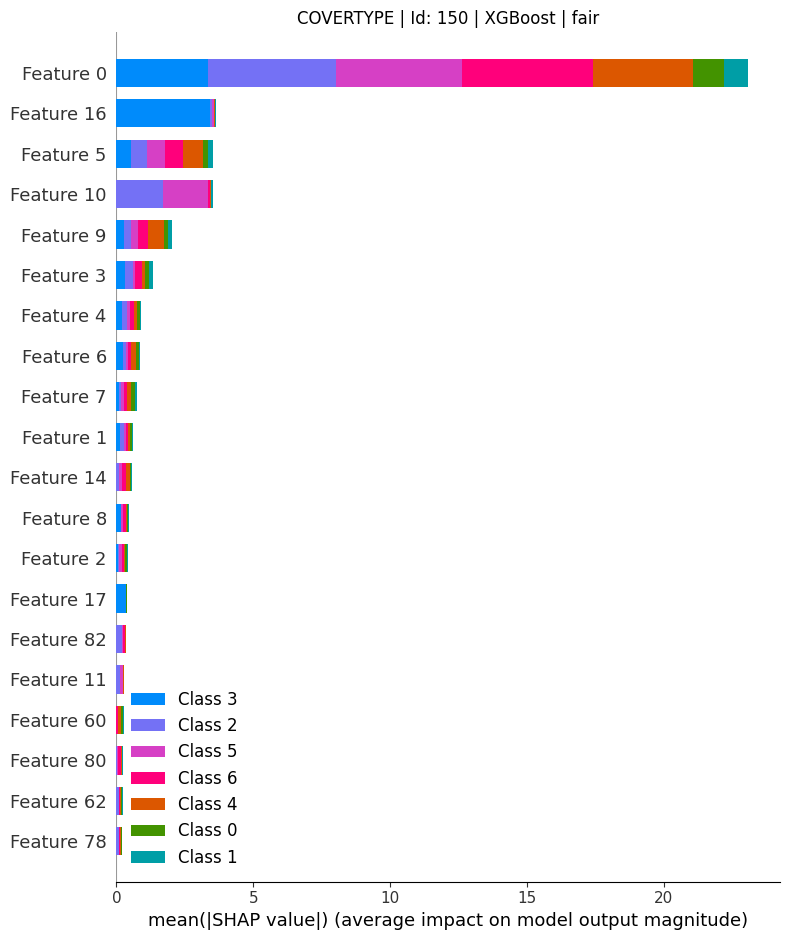


SHAP → ADULT | Id: 1590 | Model: CatBoost | Track: fair


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_612/797933537.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type="bar", show=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


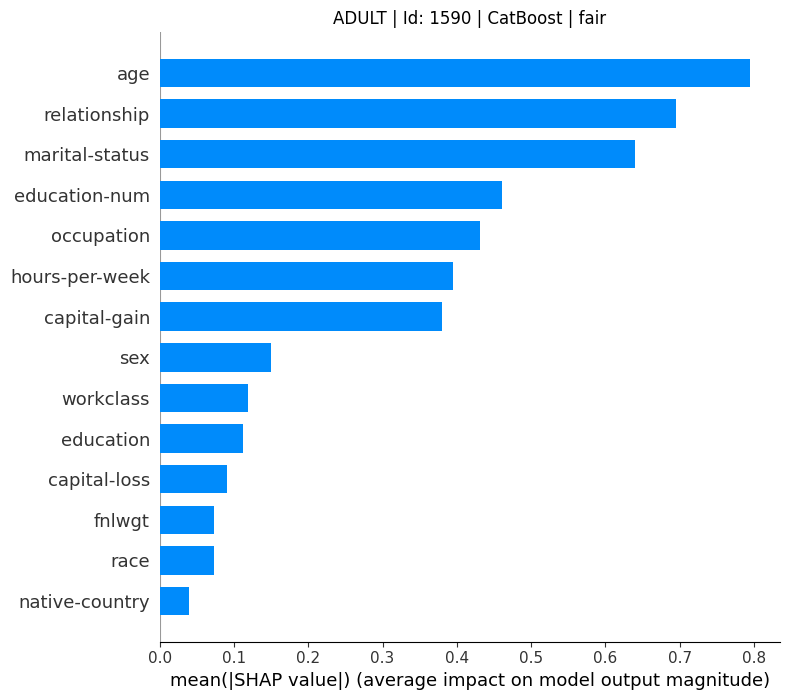


SHAP → HIGGS | Id: 23512 | Model: LightGBM | Track: fair


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_612/797933537.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type="bar", show=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled 

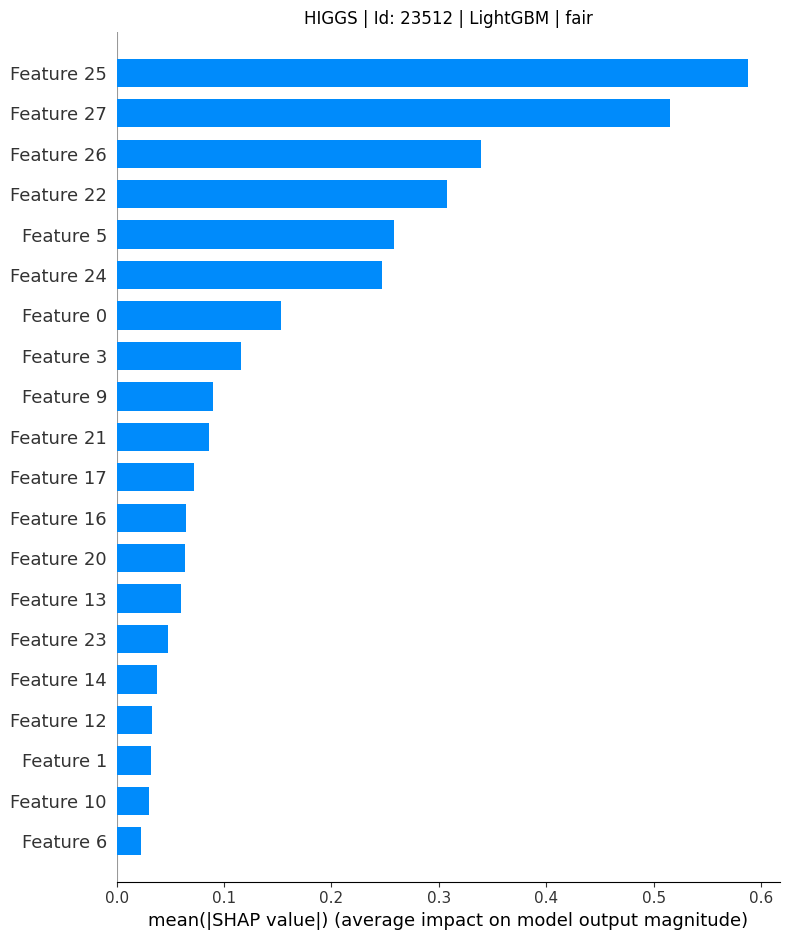


SHAP → WINE-QUALITY-WHITE | Id: 40498 | Model: XGBoost | Track: fair


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_612/797933537.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type="bar", show=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


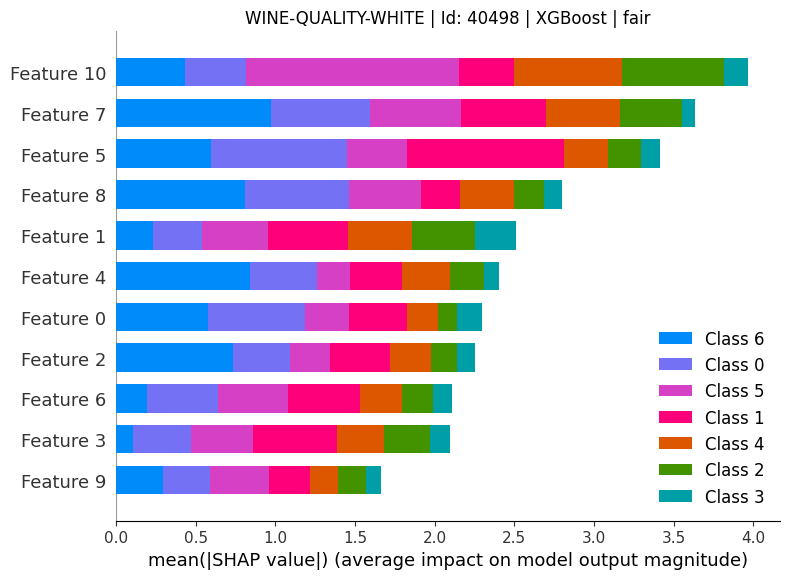


SHAP → CHURN | Id: 40701 | Model: CatBoost | Track: fair


/tmp/ipykernel_612/797933537.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type="bar", show=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


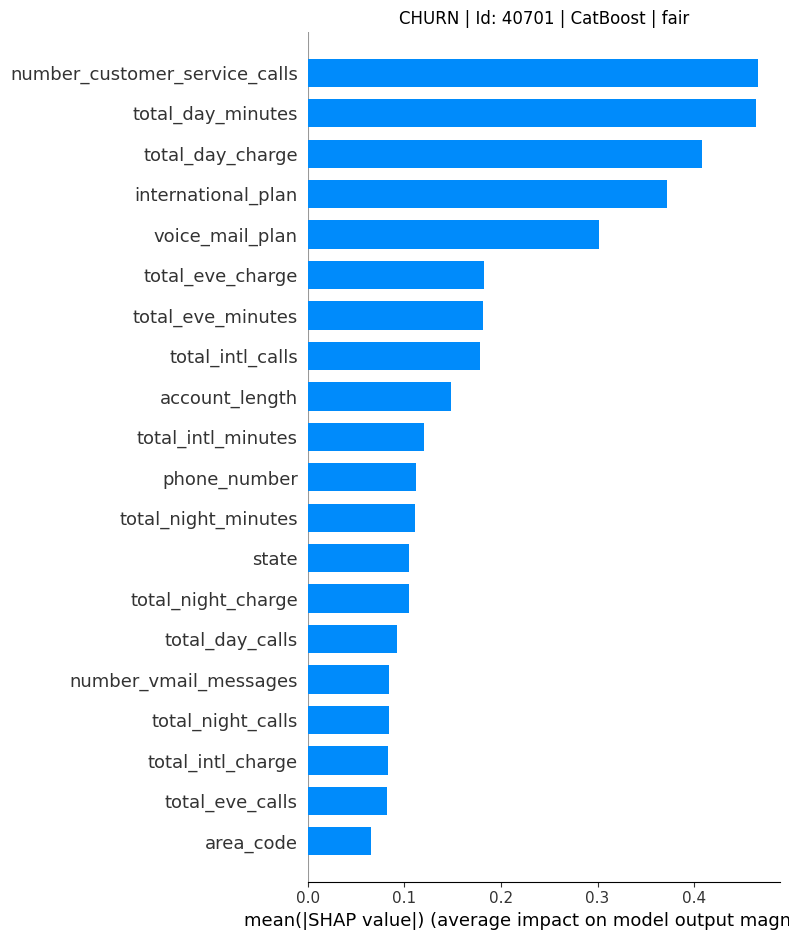

/tmp/ipykernel_612/797933537.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type="bar", show=False)



SHAP → AUSTRALIAN | Id: 40981 | Model: CatBoost | Track: fair


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


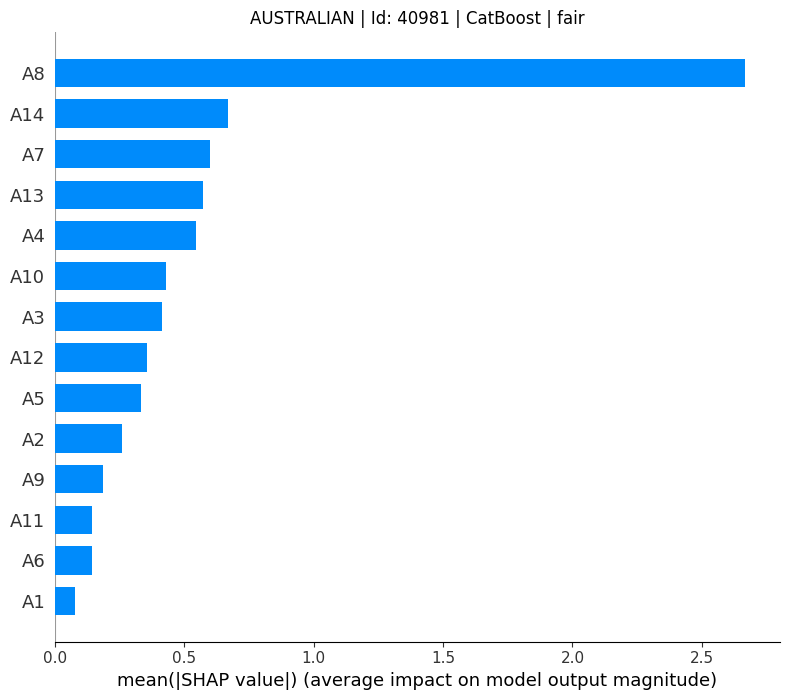


--- TRACK: REAL ---

SHAP → COVERTYPE | Id: 150 | Model: XGBoost | Track: real


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_612/797933537.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type="bar", show=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


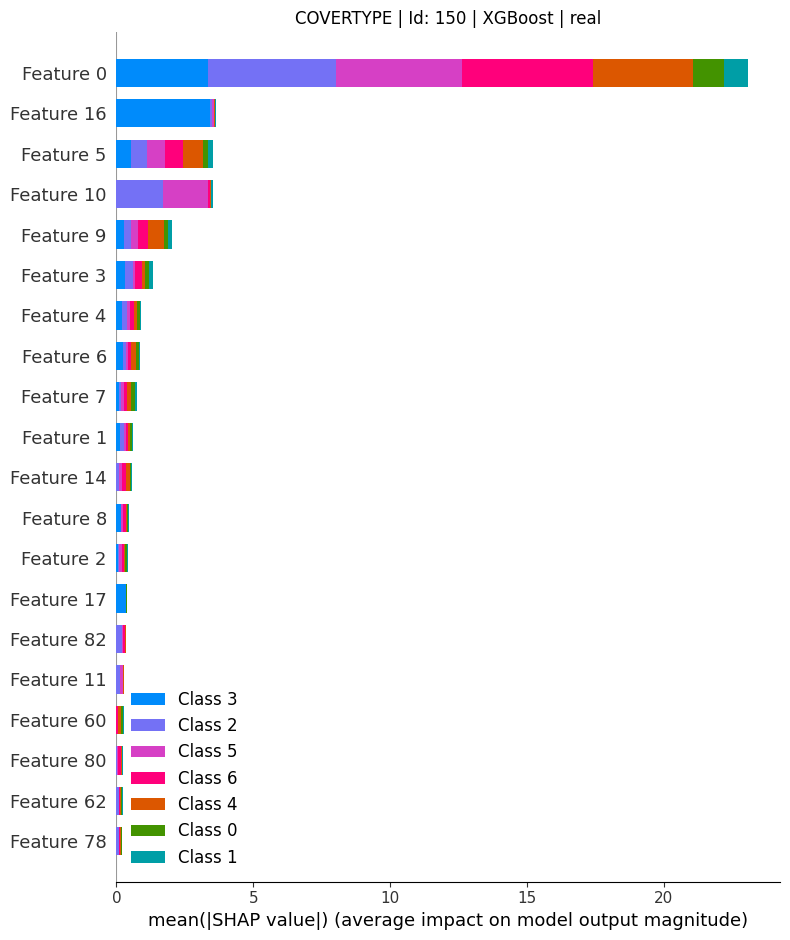


SHAP → ADULT | Id: 1590 | Model: XGBoost | Track: real


/tmp/ipykernel_612/797933537.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type="bar", show=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


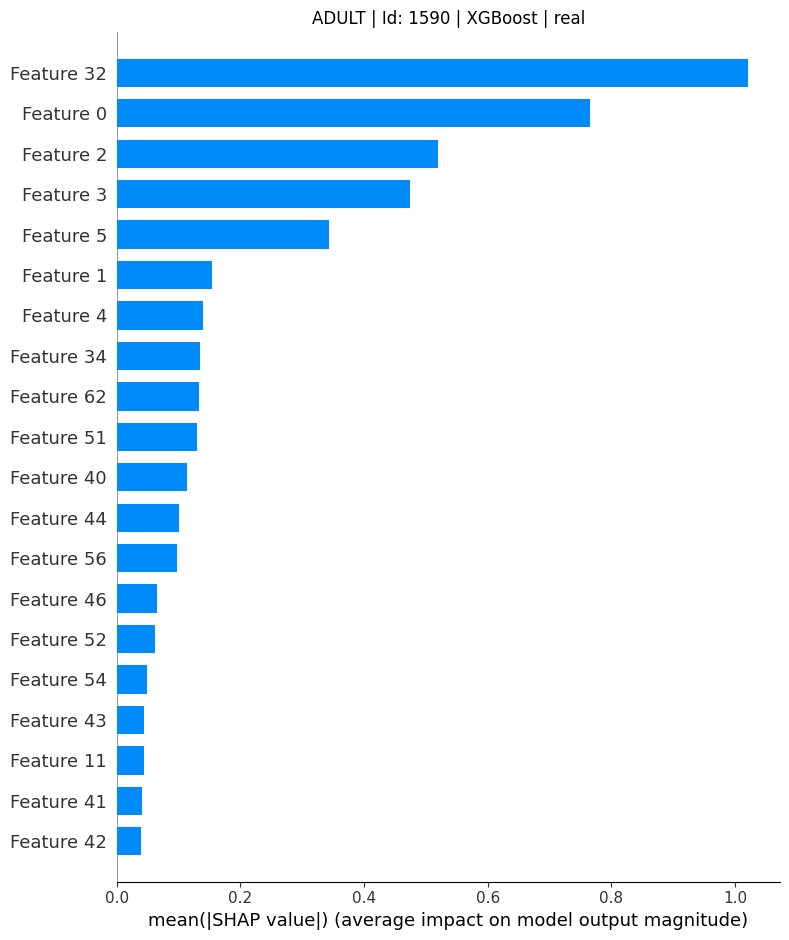


SHAP → HIGGS | Id: 23512 | Model: LightGBM | Track: real


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_612/797933537.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type="bar", show=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled 

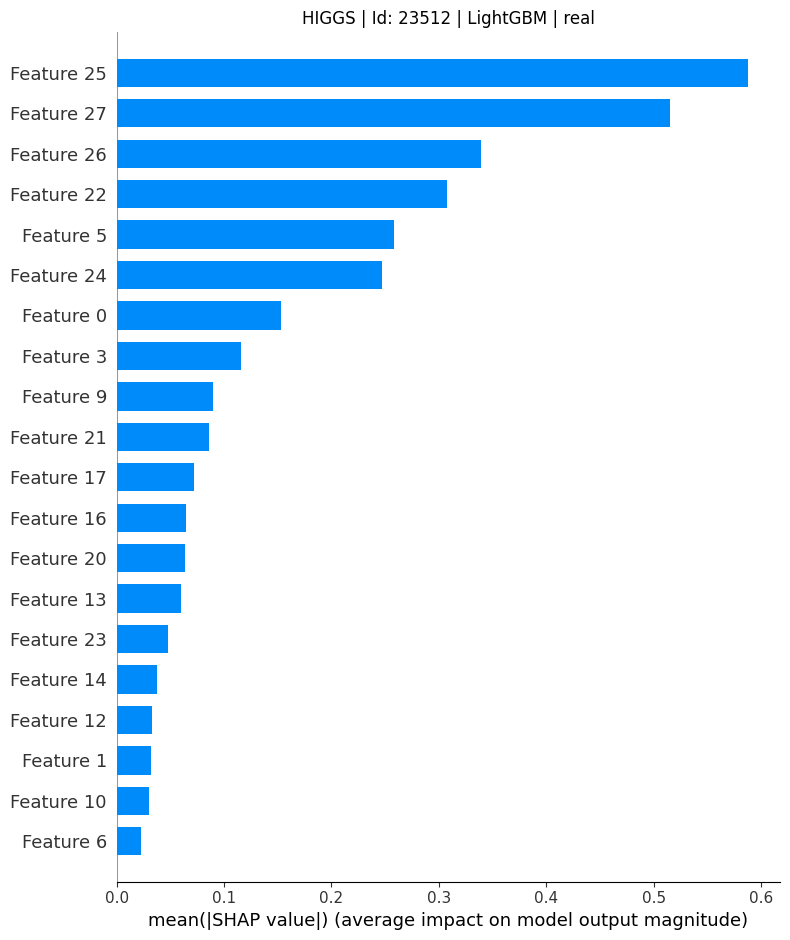


SHAP → WINE-QUALITY-WHITE | Id: 40498 | Model: LightGBM | Track: real


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_612/797933537.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type="bar", show=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


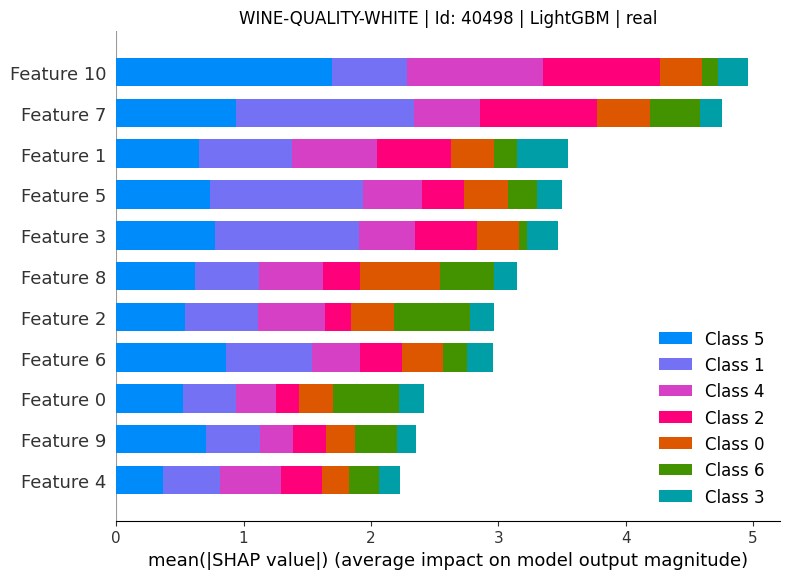


SHAP → CHURN | Id: 40701 | Model: CatBoost | Track: real


/tmp/ipykernel_612/797933537.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type="bar", show=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


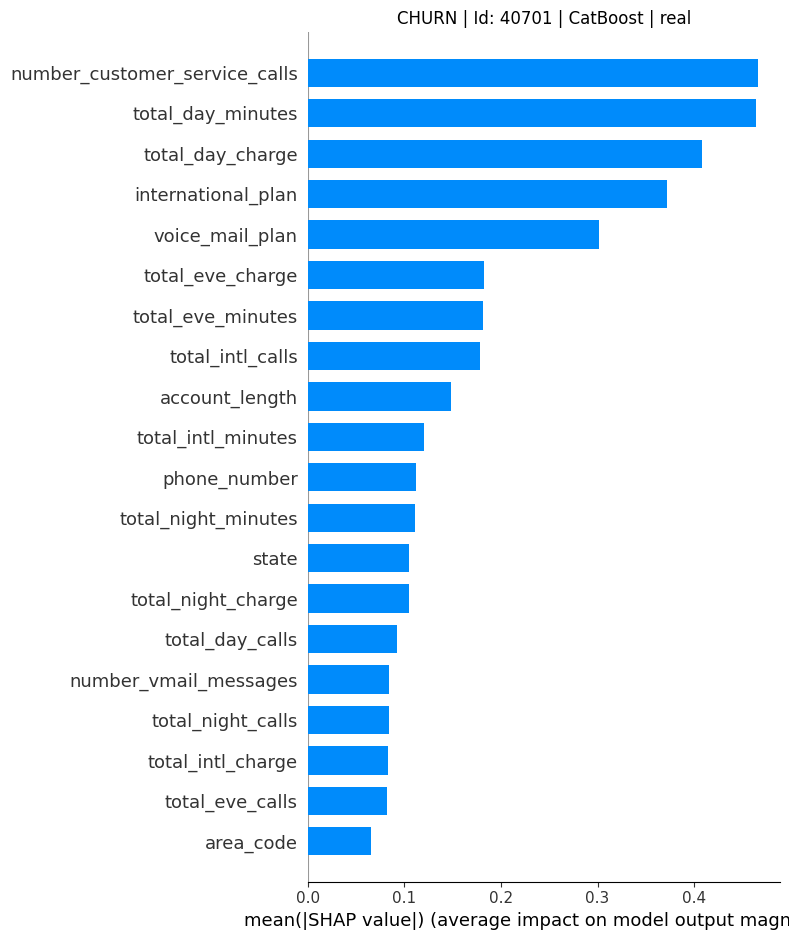

/tmp/ipykernel_612/797933537.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type="bar", show=False)



SHAP → AUSTRALIAN | Id: 40981 | Model: CatBoost | Track: real


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


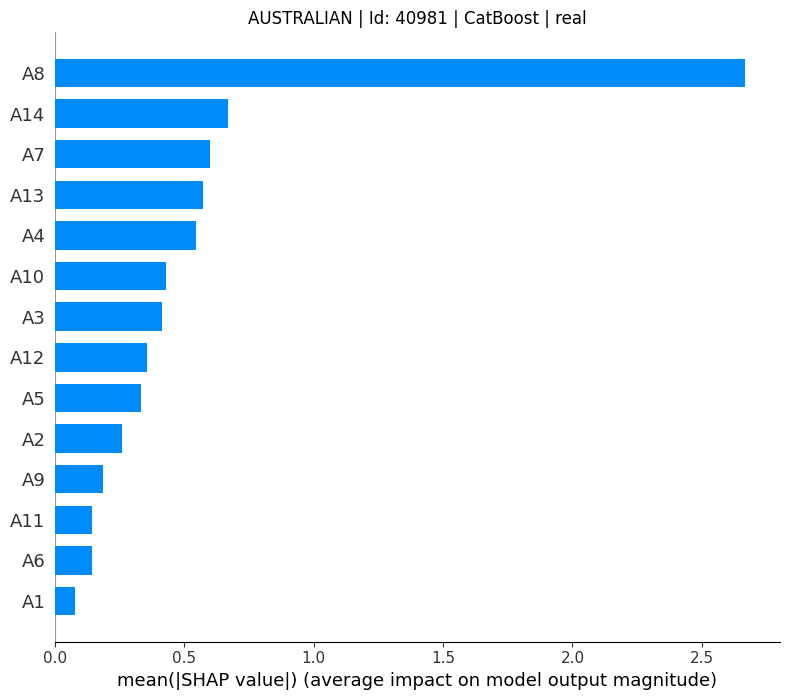

https://docs.google.com/spreadsheets/d/1MnVfig21y6qTRAtkmtSv3oM0ehxWgTriCbSL6y0tpD0/edit#gid=0


/usr/local/lib/python3.12/dist-packages/google/colab/sheets.py:331: DeprecationWarning: The order of arguments in worksheet.update() has changed. Please pass values first and range_name secondor used named arguments (range_name=, values=)
  worksheet.update(location, data, **kwargs)


https://docs.google.com/spreadsheets/d/1u6FEShvxa2Sn75wgN-D2YL5c1g1a0OxFeRoAUjsdiWI/edit#gid=0


https://docs.google.com/spreadsheets/d/1O6h3cK0XcUM-KXTeIfHMzZACh1_isGWS5l5JMftQJWA/edit#gid=0


https://docs.google.com/spreadsheets/d/15M6mH7JMo334d0SpRW2so8QjYGA2TcKGzjsv-C5AUnU/edit#gid=0


In [122]:
print("\n" + "=" * 50)
print("TÜM MODELLERİN METRİK SONUÇLARI")
print("=" * 50)

pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)

results_df = results_df.copy()

# -------------------------
# NUMERIC CAST
# -------------------------
metric_cols = [
    "CV_Macro_F1_Mean",
    "CV_Macro_F1_Std",
    "Test_Macro_F1",
    "Primary_Metric_Value",
]

for col in metric_cols:
    if col in results_df.columns:
        results_df[col] = pd.to_numeric(results_df[col], errors="coerce")

# -------------------------
# 95% CI
# -------------------------
def ci95(x):
    x = pd.Series(x).dropna()
    if len(x) <= 1:
        return np.nan
    return 1.96 * x.std(ddof=1) / np.sqrt(len(x))

# -------------------------
# SUMMARY
# -------------------------
summary_df = results_df.groupby(
    ["Track_Mode", "Dataset", "Dataset_Name", "Model"], as_index=False
).agg({
    "CV_Macro_F1_Mean": ["mean", "std", ci95],
    "Test_Macro_F1": ["mean", "std", ci95],
    "Primary_Metric_Value": ["mean", "std", ci95],
})

summary_df.columns = [
    "Track_Mode", "Dataset", "Dataset_Name", "Model",
    "CV_Macro_F1_Mean", "CV_Macro_F1_Std", "CV_Macro_F1_CI95",
    "Test_Macro_F1_Mean", "Test_Macro_F1_Std", "Test_Macro_F1_CI95",
    "Primary_Metric_Mean", "Primary_Metric_Std", "Primary_Metric_CI95",
]

# -------------------------
# DATASET BAZLI RANK
# -------------------------
summary_df["Rank"] = summary_df.groupby(["Track_Mode", "Dataset"])["Primary_Metric_Mean"] \
                               .rank(ascending=False, method="dense")

best_models_df = summary_df.loc[
    summary_df.groupby(["Track_Mode", "Dataset"])["Primary_Metric_Mean"].idxmax()
].reset_index(drop=True)

# -------------------------
# DISPLAY
# -------------------------
display_df = summary_df.copy()
best_display_df = best_models_df.copy()

numeric_cols_summary = display_df.select_dtypes(include=[np.number]).columns
numeric_cols_best = best_display_df.select_dtypes(include=[np.number]).columns

display_df[numeric_cols_summary] = display_df[numeric_cols_summary].round(4)
best_display_df[numeric_cols_best] = best_display_df[numeric_cols_best].round(4)

print("\n--- DATASET BAZLI EN İYİ MODELLER ---")
display(best_display_df.sort_values(by=["Dataset"]))

print("\n--- TÜM MODELLER (SIRALI) ---")
display(display_df.sort_values(by=["Dataset", "Rank", "Model"]))

print("\n" + "="*50)
print("FAIR vs REAL KARŞILAŞTIRMA")
print("="*50)

pivot_df = summary_df.pivot_table(
    index=["Dataset", "Model"],
    columns="Track_Mode",
    values="Primary_Metric_Mean"
).reset_index()

if "fair" not in pivot_df.columns:
    pivot_df["fair"] = np.nan
if "real" not in pivot_df.columns:
    pivot_df["real"] = np.nan

pivot_df["Diff"] = pivot_df["real"] - pivot_df["fair"]

display(pivot_df.sort_values(by="Diff", ascending=False))

# -------------------------
# EXPORT
# -------------------------
summary_df.to_csv("Gazi_ML16_Tum_Sonuclar_All_Tracks.csv", index=False)
best_models_df.to_csv("Gazi_ML16_En_Iyi_Modeller_All_Tracks.csv", index=False)
results_df.to_csv("Gazi_ML16_Ham_Sonuclar_All_Tracks.csv", index=False)
pivot_df.to_csv("Gazi_ML16_Fair_Real_Karsilastirma.csv", index=False)

print("\nCSV dosyaları kaydedildi.")

# -------------------------
# POST-HOC SHAP TRIGGER
# -------------------------
print("\n" + "=" * 50)
print("POST-HOC SHAP ANALİZİ BAŞLIYOR")
print("=" * 50)

perform_posthoc_shap(results_df, trained_models, sample_size=500)

try:
    from google.colab import sheets
    sheet1 = sheets.InteractiveSheet(df=best_models_df)
    sheet2 = sheets.InteractiveSheet(df=summary_df)
    sheet3 = sheets.InteractiveSheet(df=results_df)
    sheet4 = sheets.InteractiveSheet(df=pivot_df)
except Exception:
    print("InteractiveSheet atlandı (Colab ortamı değil).")